In [2]:
!pip install statsmodels


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
### === IMPORTS === ###
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import polars as pl
import math
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import make_scorer

In [4]:
### === DATA LODA === ###
# ----------------------------------
# Statsbomb Event Data Retrieval
# ----------------------------------
EDA_DIR = Path.cwd()  # should be .../<parent folder name>/eda
PROJECT_ROOT = Path(r"C:\Users\bapna\Downloads\soccer-analytics-capstone-team14") # .../<parent folder name>

events_df = pl.read_parquet(PROJECT_ROOT / "data" / "Statsbomb" / "events.parquet")
events_df = events_df.filter(((pl.col("period") <= 2)))

In [5]:
events_df.head()

id,index_num,period,minute,second,timestamp,duration,location_x,location_y,possession,possession_team_id,possession_team,out,off_camera,counterpress,under_pressure,type_id,type,match_id,team_id,team,player_id,player,position_id,position,play_pattern_id,play_pattern,shot_end_location_x,shot_end_location_y,shot_end_location_z,shot_statsbomb_xg,shot_outcome,shot_technique,shot_body_part,shot_type,shot_key_pass_id,shot_freeze_frame,…,dribble_overrun,dribble_no_touch,duel_type,duel_outcome,foul_committed_card,foul_committed_type,foul_committed_offensive,foul_committed_advantage,foul_committed_penalty,foul_won_defensive,foul_won_advantage,foul_won_penalty,goalkeeper_type,goalkeeper_outcome,goalkeeper_technique,goalkeeper_position,goalkeeper_body_part,goalkeeper_end_location_x,goalkeeper_end_location_y,clearance_body_part,clearance_aerial_won,clearance_head,clearance_left_foot,clearance_right_foot,interception_outcome,block_deflection,block_offensive,block_save_block,ball_recovery_offensive,ball_recovery_failure,miscontrol_aerial_won,substitution_replacement_id,substitution_replacement_name,substitution_outcome,fifty_fifty_outcome,bad_behaviour_card,injury_stoppage_in_chain
str,i32,i32,i32,i32,str,f32,f32,f32,i32,i32,str,bool,bool,bool,bool,i32,str,i32,i32,str,i32,str,i32,str,i32,str,f32,f32,f32,f32,str,str,str,str,str,str,…,bool,bool,str,str,str,str,bool,bool,bool,bool,bool,bool,str,str,str,str,str,f32,f32,str,bool,bool,bool,bool,str,bool,bool,bool,bool,bool,bool,i32,str,str,str,str,bool
"""9f6e2ecf-6685-45df-a62e-c2db30…",1,1,0,0,"""00:00:00""",0.0,null,null,1,217,"""Barcelona""",false,false,false,false,35,"""Starting XI""",15946,217,"""Barcelona""",null,null,null,null,1,"""Regular Play""",null,null,null,null,null,null,null,null,null,null,…,false,false,null,null,null,null,false,false,false,false,false,false,null,null,null,null,null,null,null,null,false,false,false,false,null,false,false,false,false,false,false,null,null,null,null,null,false
"""0300039d-150d-41e4-b29a-76602e…",2,1,0,0,"""00:00:00""",0.0,null,null,1,217,"""Barcelona""",false,false,false,false,35,"""Starting XI""",15946,206,"""Deportivo Alavés""",null,null,null,null,1,"""Regular Play""",null,null,null,null,null,null,null,null,null,null,…,false,false,null,null,null,null,false,false,false,false,false,false,null,null,null,null,null,null,null,null,false,false,false,false,null,false,false,false,false,false,false,null,null,null,null,null,false
"""491e8901-7630-4cc8-b57b-937ddd…",3,1,0,0,"""00:00:00""",0.0,null,null,1,217,"""Barcelona""",false,false,false,false,18,"""Half Start""",15946,217,"""Barcelona""",null,null,null,null,1,"""Regular Play""",null,null,null,null,null,null,null,null,null,null,…,false,false,null,null,null,null,false,false,false,false,false,false,null,null,null,null,null,null,null,null,false,false,false,false,null,false,false,false,false,false,false,null,null,null,null,null,false
"""757b85ad-ddfe-44d5-b893-c23a9f…",4,1,0,0,"""00:00:00""",0.0,null,null,1,217,"""Barcelona""",false,false,false,false,18,"""Half Start""",15946,206,"""Deportivo Alavés""",null,null,null,null,1,"""Regular Play""",null,null,null,null,null,null,null,null,null,null,…,false,false,null,null,null,null,false,false,false,false,false,false,null,null,null,null,null,null,null,null,false,false,false,false,null,false,false,false,false,false,false,null,null,null,null,null,false
"""549567bd-36de-4ac8-b8dc-6b5d3f…",5,1,0,0,"""00:00:00.575""",2.015669,61.0,40.099998,2,206,"""Deportivo Alavés""",false,false,false,false,30,"""Pass""",15946,206,"""Deportivo Alavés""",6581,"""Jonathan Rodríguez Menéndez""",16,"""Left Midfield""",9,"""From Kick Off""",null,null,null,null,null,null,null,null,null,null,…,false,false,null,null,null,null,false,false,false,false,false,false,null,null,null,null,null,null,null,null,false,false,false,false,null,false,false,false,false,false,false,null,null,null,null,null,false


# Filter matches for only Men's games occuring after 2002

In [6]:
matches = pl.read_parquet(PROJECT_ROOT / "data" / "Statsbomb" / "matches.parquet")
print("Start # rows:", matches.shape[0])
matches = matches.filter(pl.col('gender')=='male')
print("Men's games only:",matches.shape[0])
matches = matches.filter(pl.col('is_youth')==False)
print("Non-youth games only:",matches.shape[0])

matches = matches.with_columns(pl.col("match_date").str.strptime(pl.Date, strict=False))
matches = matches.with_columns(pl.col("match_date").dt.year().alias("year"))
matches = matches.filter(pl.col('year')>=2000)
print("Post 2000 games only:",matches.shape[0])

display(matches.head())

Start # rows: 3464
Men's games only: 2924
Non-youth games only: 2923
Post 2000 games only: 2889


match_id,match_date,match_week,match_status,match_status_360,kickoff,home_score,away_score,competition_id,competition,competition_stage,season_id,season,home_team_id,home_team,home_managers,away_team_id,away_team,away_managers,stadium_id,stadium,referee_id,referee,last_updated,last_updated_360,data_version,shot_fidelity_version,xy_fidelity_version,competition_name,gender,is_youth,is_international,country_name,season_name,match_updated,match_available_360,year
i32,date,i32,str,str,str,i32,i32,i32,str,str,i32,str,i32,str,str,i32,str,str,i32,str,i32,str,str,str,str,str,str,str,str,bool,bool,str,str,str,str,i32
9880,2018-04-14,32,"""available""","""scheduled""","""16:15:00""",2,1,11,"""La Liga""","""Regular Season""",1,"""2017/2018""",217,"""Barcelona""","""[{""id"":227,""name"":""Ernesto Val…",207,"""Valencia""","""[{""id"":211,""name"":""Marcelino G…",342,"""Spotify Camp Nou""",2728,"""Carlos del Cerro Grande""","""2023-02-08T17:23:53.901920""","""2021-06-13T16:17:31.694""","""1.1.0""","""2""","""2""","""La Liga""","""male""",false,false,"""Spain""","""2017/2018""","""2025-07-14T10:01:16.674864""",null,2018
9912,2018-04-29,35,"""available""","""scheduled""","""20:45:00""",2,4,11,"""La Liga""","""Regular Season""",1,"""2017/2018""",219,"""RC Deportivo La Coruña""","""[{""id"":371,""name"":""Clarence Se…",217,"""Barcelona""","""[{""id"":227,""name"":""Ernesto Val…",4658,"""Estadio Abanca-Riazor""",2602,"""Ricardo De Burgos Bengoetxea""","""2022-12-05T14:42:44.641092""","""2021-06-13T16:17:31.694""","""1.1.0""","""2""","""2""","""La Liga""","""male""",false,false,"""Spain""","""2017/2018""","""2025-07-14T10:01:16.674864""",null,2018
9924,2018-05-06,36,"""available""","""scheduled""","""20:45:00""",2,2,11,"""La Liga""","""Regular Season""",1,"""2017/2018""",217,"""Barcelona""","""[{""id"":227,""name"":""Ernesto Val…",220,"""Real Madrid""","""[{""id"":56,""name"":""Zinédine Zid…",342,"""Spotify Camp Nou""",2608,"""Alejandro José Hernández Herná…","""2022-12-01T03:25:12.063586""","""2021-06-13T16:17:31.694""","""1.1.0""","""2""","""2""","""La Liga""","""male""",false,false,"""Spain""","""2017/2018""","""2025-07-14T10:01:16.674864""",null,2018
9855,2018-03-18,29,"""available""","""scheduled""","""16:15:00""",2,0,11,"""La Liga""","""Regular Season""",1,"""2017/2018""",217,"""Barcelona""","""[{""id"":227,""name"":""Ernesto Val…",215,"""Athletic Club""","""[{""id"":210,""name"":""José Ángel …",342,"""Spotify Camp Nou""",2575,"""Santiago Jaime Latre""","""2022-12-01T02:33:31.178193""","""2021-06-13T16:17:31.694""","""1.1.0""","""2""","""2""","""La Liga""","""male""",false,false,"""Spain""","""2017/2018""","""2025-07-14T10:01:16.674864""",null,2018
9827,2018-03-01,26,"""available""","""scheduled""","""21:00:00""",1,1,11,"""La Liga""","""Regular Season""",1,"""2017/2018""",208,"""Las Palmas""","""[{""id"":220,""name"":""Francisco J…",217,"""Barcelona""","""[{""id"":227,""name"":""Ernesto Val…",357,"""Estadio de Gran Canaria""",180,"""Antonio Miguel Mateu Lahoz""","""2022-08-04T17:18:06.540844""","""2021-06-13T16:17:31.694""","""1.1.0""","""2""","""2""","""La Liga""","""male""",false,false,"""Spain""","""2017/2018""","""2025-07-14T10:01:16.674864""",null,2018


In [7]:
def create_match_results_matrix(e, m, ot=False):      
    '''
    Build feature df in time window(s) (same columns as full-game df)
    '''
    # carry / dribble / pass volume
    team_vol = (
        e.group_by(["match_id","team"])
         .agg([
             (pl.col("type") == "Carry").sum().alias("n_carries"),
             (pl.col("type") == "Dribble").sum().alias("n_dribbles"),
             (pl.col("type") == "Pass").sum().alias("n_passes"),
             ((pl.col("type") == "Pass") & (pl.col("pass_outcome").is_null()))
                 .sum().alias("n_passes_complete"),
         ])
    )
    
    # shots + xg
    team_shots = e.filter(pl.col("type") == "Shot").group_by(["match_id","team"]).agg(pl.len().alias("shots"))
    team_xg = e.filter(pl.col("type") == "Shot").group_by(["match_id","team"]).agg(pl.col("shot_statsbomb_xg").sum().alias("xg_for"))
    
    # shots on target
    sot_outcomes = ["Goal", "Saved", "Saved to Post", "Saved Off Target"]
    team_sot = (
        e.filter((pl.col("type") == "Shot") & (pl.col("shot_outcome").is_in(sot_outcomes)))
         .group_by(["match_id","team"])
         .agg(pl.len().alias("shots_on_target"))
    )
    
    # pressures
    team_press = e.filter(pl.col("type") == "Pressure").group_by(["match_id","team"]).agg(pl.len().alias("pressures"))
    
    # final third entries (pass/carry end x > 80)
    team_ft_pass = e.filter((pl.col("type")=="Pass") & (pl.col("pass_end_location_x") > 80)).group_by(["match_id","team"]).agg(pl.len().alias("final_third_passes"))
    team_ft_carry = e.filter((pl.col("type")=="Carry") & (pl.col("carry_end_location_x") > 80)).group_by(["match_id","team"]).agg(pl.len().alias("final_third_carries"))

    if ot:
        # ------------------------------------------------------------
        # Build spine from provided event window (e)
        # ------------------------------------------------------------
        spine = (
            e.select(["match_id","team"])
             .unique()
        )
        
        # ------------------------------------------------------------
        # Start from event-based spine instead of m
        # ------------------------------------------------------------
        df_h1 = (
            spine
            .join(m, on=["match_id","team"], how="left")
            .join(team_shots, on=["match_id","team"], how="left")
            .join(team_xg, on=["match_id","team"], how="left")
            .join(team_sot, on=["match_id","team"], how="left")
            .join(team_press, on=["match_id","team"], how="left")
            .join(team_ft_pass, on=["match_id","team"], how="left")
            .join(team_ft_carry, on=["match_id","team"], how="left")
            .join(team_vol, on=["match_id","team"], how="left")
            .with_columns([
                pl.col("shots").fill_null(0).cast(pl.Int64),
                pl.col("shots_on_target").fill_null(0).cast(pl.Int64),
                pl.col("pressures").fill_null(0).cast(pl.Int64),
                pl.col("final_third_passes").fill_null(0).cast(pl.Int64),
                pl.col("final_third_carries").fill_null(0).cast(pl.Int64),
                pl.col("xg_for").fill_null(0.0),
            ])
            .with_columns(
                (pl.col("final_third_passes") + pl.col("final_third_carries")).alias("final_third_entries")
            )
        )
    else:
        # start from m spine and join features
        df_h1 = (
            m
            .join(team_shots, on=["match_id","team"], how="left")
            .join(team_xg, on=["match_id","team"], how="left")
            .join(team_sot, on=["match_id","team"], how="left")
            .join(team_press, on=["match_id","team"], how="left")
            .join(team_ft_pass, on=["match_id","team"], how="left")
            .join(team_ft_carry, on=["match_id","team"], how="left")
            .join(team_vol, on=["match_id","team"], how="left")
            .with_columns([
                pl.col("shots").fill_null(0).cast(pl.Int64),
                pl.col("shots_on_target").fill_null(0).cast(pl.Int64),
                pl.col("pressures").fill_null(0).cast(pl.Int64),
                pl.col("final_third_passes").fill_null(0).cast(pl.Int64),
                pl.col("final_third_carries").fill_null(0).cast(pl.Int64),
                pl.col("xg_for").fill_null(0.0),
            ])
            .with_columns(
                (pl.col("final_third_passes") + pl.col("final_third_carries")).alias("final_third_entries")
            )
        )
    
    # add opponent ("against") + diffs (cast to signed first to avoid u64 underflow)
    df_h1 = df_h1.with_columns([
        pl.col("goals_scored").cast(pl.Int64),
        pl.col("shots").cast(pl.Int64),
        pl.col("shots_on_target").cast(pl.Int64),
        pl.col("final_third_entries").cast(pl.Int64),
        pl.col("pressures").cast(pl.Int64),
    ])
    
    df_h1 = (
        df_h1
        .with_columns([
            pl.col("goals_scored").sum().over("match_id").alias("match_goals_total"),
            pl.col("shots").sum().over("match_id").alias("match_shots_total"),
            pl.col("shots_on_target").sum().over("match_id").alias("match_sot_total"),
            pl.col("xg_for").sum().over("match_id").alias("match_xg_total"),
            pl.col("final_third_entries").sum().over("match_id").alias("match_ft_total"),
            pl.col("pressures").sum().over("match_id").alias("match_press_total"),
        ])
        .with_columns([
            (pl.col("match_goals_total") - pl.col("goals_scored")).alias("goals_conceded"),
            (pl.col("match_shots_total") - pl.col("shots")).alias("shots_against"),
            (pl.col("match_sot_total") - pl.col("shots_on_target")).alias("sot_against"),
            (pl.col("match_xg_total") - pl.col("xg_for")).alias("xg_against"),
            (pl.col("match_ft_total") - pl.col("final_third_entries")).alias("final_third_against"),
            (pl.col("match_press_total") - pl.col("pressures")).alias("pressure_against"),
        ])
        .with_columns([
            (pl.col("goals_scored") - pl.col("goals_conceded")).alias("goal_diff"),
            (pl.col("shots") - pl.col("shots_against")).alias("shot_diff"),
            (pl.col("shots_on_target") - pl.col("sot_against")).alias("sot_diff"),
            (pl.col("xg_for") - pl.col("xg_against")).alias("xg_diff"),
            (pl.col("final_third_entries") - pl.col("final_third_against")).alias("final_third_diff"),
            (pl.col("pressures") - pl.col("pressure_against")).alias("pressure_diff"),
        ])
        .with_columns([
            pl.col("n_carries").fill_null(0).cast(pl.Int64),
            pl.col("n_dribbles").fill_null(0).cast(pl.Int64),
            pl.col("n_passes").fill_null(0).cast(pl.Int64),
            pl.col("n_passes_complete").fill_null(0).cast(pl.Int64),
            (pl.col("n_passes_complete") / pl.when(pl.col("n_passes") > 0)
                 .then(pl.col("n_passes"))
                 .otherwise(None)).alias("pass_completion_rate")
        ])
        .drop([
            "match_goals_total","match_shots_total","match_sot_total",
            "match_xg_total","match_ft_total","match_press_total"
        ])
    )
    
    df_h1 = (
        df_h1
        .with_columns([
            pl.col("n_carries").cast(pl.Int64).alias("n_carries_i"),
            pl.col("n_dribbles").cast(pl.Int64).alias("n_dribbles_i"),
            pl.col("n_passes").cast(pl.Int64).alias("n_passes_i"),
            pl.col("n_passes_complete").cast(pl.Int64).alias("n_passes_complete_i"),
        ])
        .with_columns([
            pl.col("n_carries_i").sum().over("match_id").alias("match_total_carries"),
            pl.col("n_dribbles_i").sum().over("match_id").alias("match_total_dribbles"),
            pl.col("n_passes_i").sum().over("match_id").alias("match_total_passes"),
            pl.col("n_passes_complete_i").sum().over("match_id").alias("match_total_passes_complete"),
        ])
        .with_columns([
            (pl.col("match_total_carries") - pl.col("n_carries_i")).alias("carries_against"),
            (pl.col("match_total_dribbles") - pl.col("n_dribbles_i")).alias("dribbles_against"),
            (pl.col("match_total_passes") - pl.col("n_passes_i")).alias("passes_against"),
            (pl.col("match_total_passes_complete") - pl.col("n_passes_complete_i")).alias("passes_complete_against"),
        ])
        .with_columns([
            (pl.col("n_carries_i") - pl.col("carries_against")).alias("carry_diff"),
            (pl.col("n_dribbles_i") - pl.col("dribbles_against")).alias("dribble_diff"),
            (pl.col("n_passes_i") - pl.col("passes_against")).alias("pass_diff"),
            (pl.col("n_passes_complete_i") - pl.col("passes_complete_against")).alias("pass_complete_diff"),
        ])
        .drop([
            "n_carries_i","n_dribbles_i","n_passes_i","n_passes_complete_i",
            "match_total_carries","match_total_dribbles","match_total_passes","match_total_passes_complete",
        ])
    )

    # add binary win loss column. Ties are populated with 'None' for later filtering
    df_h1 = df_h1.with_columns(
        pl.when(pl.col("result") == "Win").then(pl.lit(1))
          .when(pl.col("result") == "Loss").then(pl.lit(0))
          .otherwise(None)
          .cast(pl.Int8)
          .alias("win")
    )
    
    return df_h1

In [8]:
def corr_series(corr_df, target, features, label):
    '''
    BUILD CORRELATION COMPARISON FUNCTION
    '''
    cols = corr_df.columns
    i = cols.index(target)
    vals = corr_df.row(i)
    return pd.Series({c: float(v) for c, v in zip(cols, vals) if c in features}, name=label)

In [9]:
def plot_corrs(targets, corr_dfs, features=None, magnitude=False, figsize=(14, 5)):
    """
    targets: list[str]                       e.g. ["goal_diff", "xg_diff"]
    corr_dfs: dict[str, polars.DataFrame]    e.g. {"All": corr_df, "H1": corr_df_h1, "Q1+Q3": corr_df_q13, "Q4": corr_df_q4}
    features: list[str]                      x-axis features (sorted alphabetically for consistent order)
    """
    if features is None:
        features = ["goal_diff", "xg_diff", "sot_diff", "shot_diff", "final_third_diff", "pressure_diff"]
    # features = sorted(features)

    for target in targets:
        series_list = [
            corr_series(df, target, features, label)
            for label, df in corr_dfs.items()
        ]

        plot_df = pd.concat(series_list, axis=1).loc[features]
        plot_data = plot_df.abs() if magnitude else plot_df

        ax = plot_data.plot(kind="bar", figsize=figsize, width=0.8)
        if not magnitude:
            ax.axhline(0, linewidth=1)

        for container in ax.containers:
            ax.bar_label(container, fmt="%.2f", label_type="edge", padding=2, fontsize=7)

        ax.set_title(f"{'|corr|' if magnitude else 'corr'} with {target}")
        ax.set_ylabel(f"{'|corr|' if magnitude else 'corr'}")
        ax.set_xlabel("")
        ax.legend(title="")
        plt.xticks(rotation=0)
        plt.grid(True, which="major", axis="y", linestyle="--", linewidth=0.5)
        plt.tight_layout()
        plt.show()

In [10]:
def prepare_model_data(df, feature_cols):
    '''
    FUNCTION TO PREPARE X AND y FOR MODELING: inputs = dataframe, feature vars (list); Returns = X (np.ndarray), y (np.ndarray)
    '''
    # print("Starting # of rows   :", df.shape[0])
    model_df = df.filter(pl.col("win").is_not_null())
    # print("Post filter # of rows:", model_df.shape[0])
    X = model_df.select(feature_cols).to_pandas()
    y = model_df.select("win").to_numpy().ravel()
    return X, y

In [11]:
# === CUSTOM FUNCTION TO SAVE MODEL PERFORMANCE METRICS FOR LATER COMPARISON ===
def cv_metrics(acc_scores, auc_scores, model_name):
    return pd.DataFrame([{
        "Model": model_name,
        "Accuracy Mean": np.mean(acc_scores),
        "Accuracy StD":  np.std(acc_scores),
        "AUC Mean": np.mean(auc_scores),
        "AUC StD":  np.std(auc_scores),
    }]).round(3)

In [12]:
# === CUSTOM BIC FUNCTION FOR MODEL SELECTION / EVALUATION ===
def compute_bic(X, y):
    X_const = sm.add_constant(X)
    model = sm.Logit(y, X_const).fit(disp=False)
    return model.bic, model

In [13]:
### === CREATE MATCH RESULTS TABLE === ###
# ----------------------------------
# Initiate match results table 
# ----------------------------------
match_results = (events_df.filter((pl.col("type") == "Shot") & (pl.col("shot_outcome") == "Goal"))
    .group_by(["match_id", "team"]).agg(pl.len().alias("goals_scored")))

# left join with unique match/team combo to add teams that did not score any goals
all_team_matches = (events_df.select(["match_id", "team"]).unique()) # All team–match combinations observed in events
match_results = (all_team_matches.join(match_results, on=["match_id", "team"], how="left").with_columns(pl.col("goals_scored").fill_null(0)))

# ----------------------------------------
# === add match result column ===
# ----------------------------------------
match_results = (match_results.with_columns([pl.col("goals_scored").max().over("match_id").alias("goals_max"),pl.col("goals_scored").min().over("match_id").alias("goals_min"),])
    .with_columns(pl.when(pl.col("goals_max") == pl.col("goals_min")).then(pl.lit("Draw"))
        .when(pl.col("goals_scored") == pl.col("goals_max")).then(pl.lit("Win")).otherwise(pl.lit("Loss")).alias("result"))
    .drop(["goals_max", "goals_min"]).sort("match_id"))
# display(match_results.head(5))

In [14]:
match_results.head()

match_id,team,goals_scored,result
i32,str,u32,str
7298,"""Chelsea FCW""",2,"""Draw"""
7298,"""Manchester City WFC""",2,"""Draw"""
7430,"""North Carolina Courage""",4,"""Win"""
7430,"""Washington Spirit""",2,"""Loss"""
7443,"""Portland Thorns""",2,"""Loss"""


In [15]:
### === initial match results function call on all events data === ###
match_results_matrix = create_match_results_matrix(events_df, match_results) 

In [16]:
match_results_matrix.head()

match_id,team,goals_scored,result,shots,xg_for,shots_on_target,pressures,final_third_passes,final_third_carries,n_carries,n_dribbles,n_passes,n_passes_complete,final_third_entries,goals_conceded,shots_against,sot_against,xg_against,final_third_against,pressure_against,goal_diff,shot_diff,sot_diff,xg_diff,final_third_diff,pressure_diff,pass_completion_rate,carries_against,dribbles_against,passes_against,passes_complete_against,carry_diff,dribble_diff,pass_diff,pass_complete_diff,win
i32,str,i64,str,i64,f32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f32,i64,i64,i64,i64,i64,f32,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i8
7298,"""Chelsea FCW""",2,"""Draw""",25,2.972968,7,249,217,169,426,41,521,394,386,2,9,5,1.107514,225,221,0,16,2,1.865454,161,28,0.756238,407,17,479,360,19,24,42,34,null
7298,"""Manchester City WFC""",2,"""Draw""",9,1.107514,5,221,128,97,407,17,479,360,225,2,25,7,2.972968,386,249,0,-16,-2,-1.865454,-161,-28,0.751566,426,41,521,394,-19,-24,-42,-34,null
7430,"""North Carolina Courage""",4,"""Win""",17,2.152028,10,167,187,117,378,24,444,301,304,2,8,3,0.948216,206,198,2,9,7,1.203812,98,-31,0.677928,386,37,476,329,-8,-13,-32,-28,1
7430,"""Washington Spirit""",2,"""Loss""",8,0.948216,3,198,120,86,386,37,476,329,206,4,17,10,2.152028,304,167,-2,-9,-7,-1.203812,-98,31,0.691176,378,24,444,301,8,13,32,28,0
7443,"""Portland Thorns""",2,"""Loss""",24,3.867489,10,145,177,126,359,36,441,297,303,3,13,7,1.857566,214,156,-1,11,3,2.009923,89,-11,0.673469,255,22,362,229,104,14,79,68,0


In [17]:
### add match date column ###
df = (match_results_matrix.join(matches.select(["match_id", "match_date", "year"]),
        on="match_id",
        how="inner")
    # .with_columns(
    #     pl.col("match_date").str.strptime(pl.Date, strict=False))
     )

# ### add match year column ###
# df = df.with_columns(
#     pl.col("match_date").dt.year().alias("year")
# )

In [18]:
print(df.shape[0])
df.head()

5778


match_id,team,goals_scored,result,shots,xg_for,shots_on_target,pressures,final_third_passes,final_third_carries,n_carries,n_dribbles,n_passes,n_passes_complete,final_third_entries,goals_conceded,shots_against,sot_against,xg_against,final_third_against,pressure_against,goal_diff,shot_diff,sot_diff,xg_diff,final_third_diff,pressure_diff,pass_completion_rate,carries_against,dribbles_against,passes_against,passes_complete_against,carry_diff,dribble_diff,pass_diff,pass_complete_diff,win,match_date,year
i32,str,i64,str,i64,f32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f32,i64,i64,i64,i64,i64,f32,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i8,date,i32
7525,"""Russia""",5,"""Win""",14,1.281601,7,147,148,105,269,12,388,272,253,0,6,0,0.248806,209,121,5,8,7,1.032795,44,26,0.701031,440,11,572,458,-171,1,-184,-186,1,2018-06-14,2018
7525,"""Saudi Arabia""",0,"""Loss""",6,0.248807,0,121,122,87,440,11,572,458,209,5,14,7,1.281601,253,147,-5,-8,-7,-1.032795,-44,-26,0.800699,269,12,388,272,171,-1,184,186,0,2018-06-14,2018
7529,"""Croatia""",1,"""Win""",11,1.694467,2,160,148,89,399,10,503,389,237,0,13,2,0.762322,176,152,1,-2,0,0.932145,61,8,0.77336,317,16,425,319,82,-6,78,70,1,2018-06-16,2018
7529,"""Nigeria""",0,"""Loss""",13,0.762322,2,152,107,69,317,16,425,319,176,1,11,2,1.694467,237,160,-1,2,0,-0.932145,-61,-8,0.750588,399,10,503,389,-82,6,-78,-70,0,2018-06-16,2018
7530,"""Australia""",1,"""Draw""",5,0.980031,2,113,100,50,345,5,444,342,150,1,12,4,1.561557,313,136,0,-7,-2,-0.581526,-163,-23,0.77027,454,25,549,445,-109,-20,-105,-103,null,2018-06-16,2018


In [19]:
# ### sample size inspection ###
# plt.figure(figsize=(8,4))
# plt.bar(ts_pd["year"], ts_pd["games"])
# plt.title("Number of Games per Year")
# plt.xlabel("Year")
# plt.ylabel("Games")
# plt.grid(axis="y", linestyle="--", linewidth=0.6)
# plt.show()

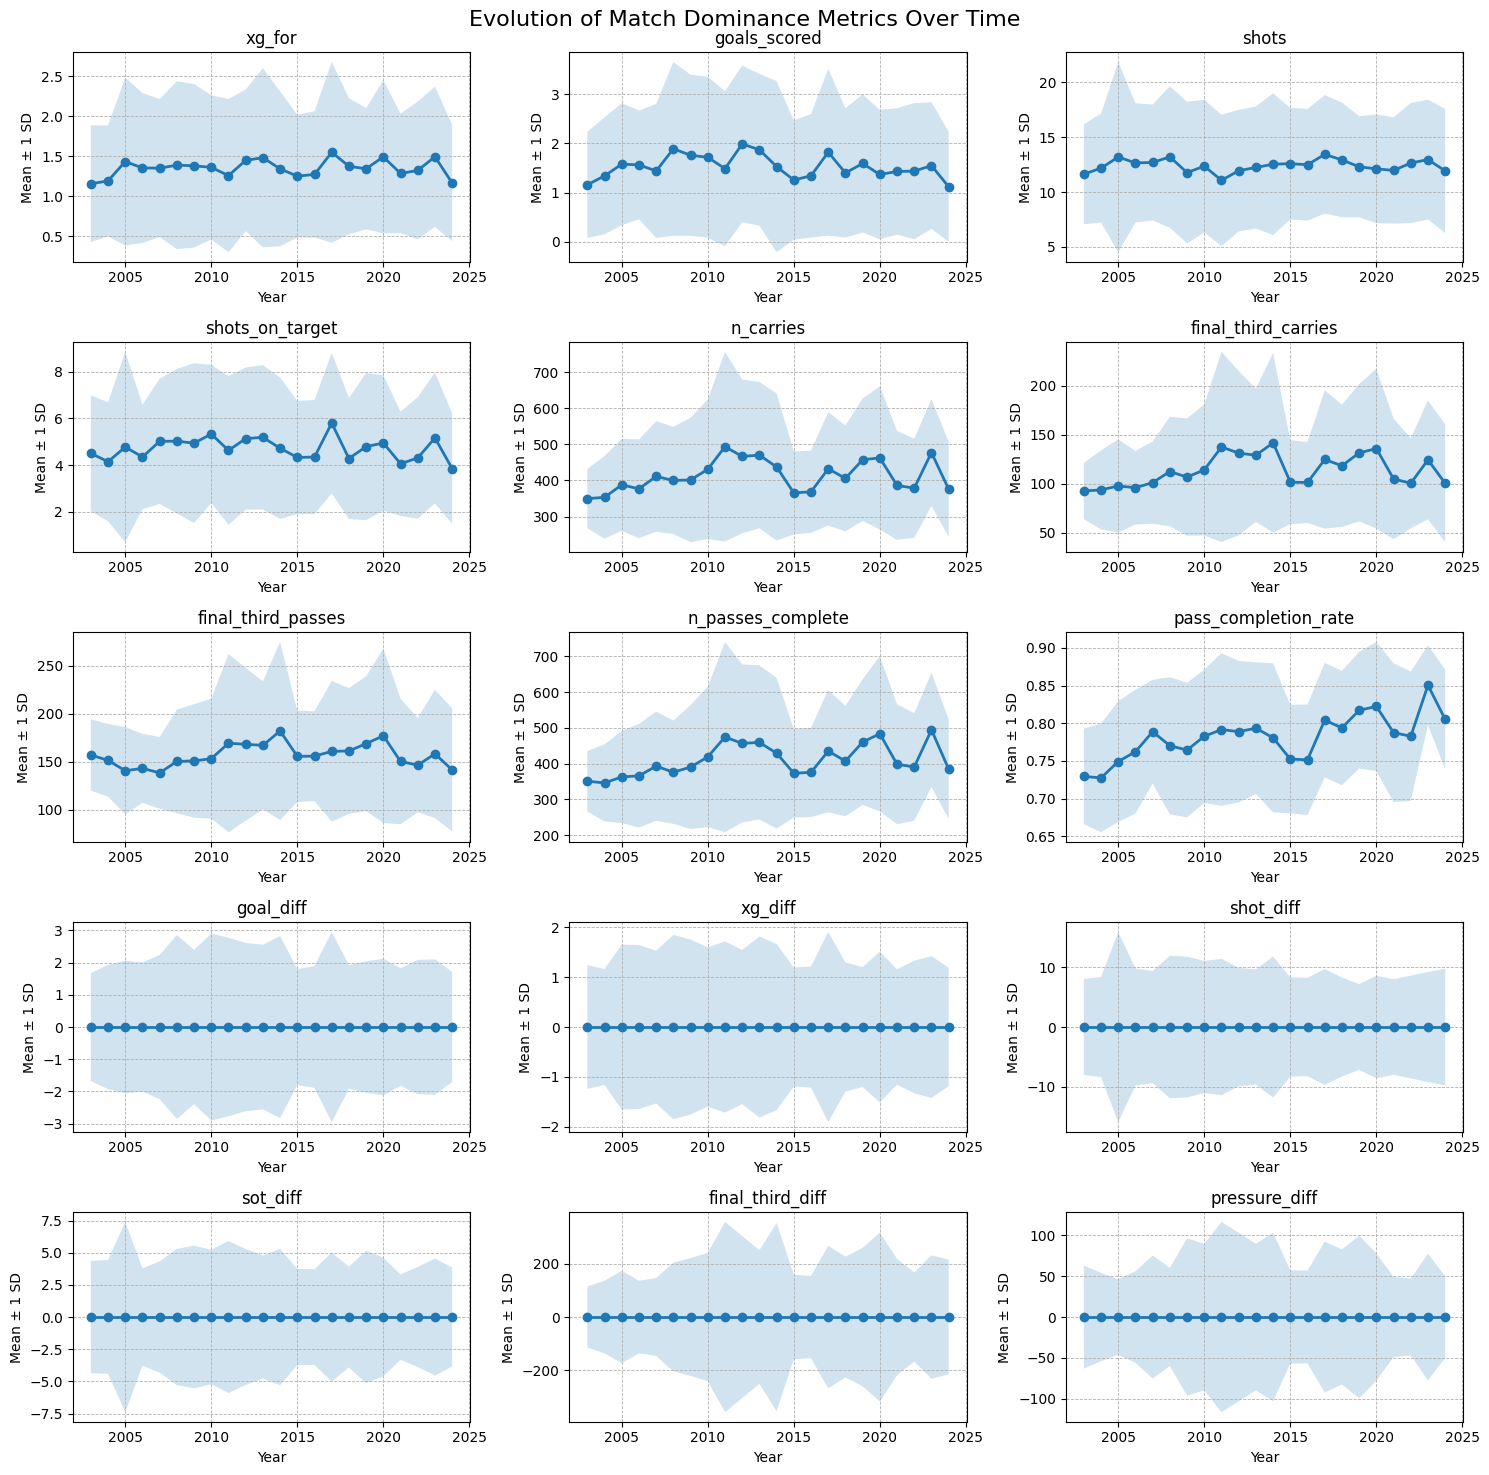

In [20]:
features = ["xg_for", "goals_scored","shots",
            "shots_on_target", "n_carries", "final_third_carries", 
            "final_third_passes", "n_passes_complete", "pass_completion_rate", 
           "goal_diff","xg_diff","shot_diff",
            "sot_diff","final_third_diff","pressure_diff"]

ts_stats = (df.group_by("year")
    .agg(pl.len().alias("games"),
        *[pl.col(f).mean().alias(f"{f}_mean") for f in features],
        *[pl.col(f).std().alias(f"{f}_std") for f in features],
    ).sort("year"))


# # reorder columns alphabetically (except year first)
# cols = ["year"] + sorted([c for c in ts_stats.columns if c != "year"])
# ts_stats = ts_stats.select(cols)

# filter by sample size
ts_pd = ts_stats.to_pandas()
ts_pd = ts_pd[ts_pd['games'] > 15]

fig, axes = plt.subplots(5, 3, figsize=(15, 15))
axes = axes.flatten()

for i, f in enumerate(features):

    mean_col = f"{f}_mean"
    std_col = f"{f}_std"

    axes[i].plot(
        ts_pd["year"],
        ts_pd[mean_col],
        marker="o",
        linewidth=2
    )

    axes[i].fill_between(
        ts_pd["year"],
        ts_pd[mean_col] - ts_pd[std_col],
        ts_pd[mean_col] + ts_pd[std_col],
        alpha=0.2
    )

    axes[i].set_title(f"{f}")
    axes[i].set_xlabel("Year")
    axes[i].set_ylabel("Mean ± 1 SD")
    axes[i].grid(True, linestyle="--", linewidth=0.6)

plt.suptitle("Evolution of Match Dominance Metrics Over Time", fontsize=16)
plt.tight_layout()
plt.show()

In [21]:
ts_stats.head()

year,games,xg_for_mean,goals_scored_mean,shots_mean,shots_on_target_mean,n_carries_mean,final_third_carries_mean,final_third_passes_mean,n_passes_complete_mean,pass_completion_rate_mean,goal_diff_mean,xg_diff_mean,shot_diff_mean,sot_diff_mean,final_third_diff_mean,pressure_diff_mean,xg_for_std,goals_scored_std,shots_std,shots_on_target_std,n_carries_std,final_third_carries_std,final_third_passes_std,n_passes_complete_std,pass_completion_rate_std,goal_diff_std,xg_diff_std,shot_diff_std,sot_diff_std,final_third_diff_std,pressure_diff_std
i32,u32,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f32,f64,f64,f64,f64,f32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f32,f64,f64,f64,f64
2003,38,1.153991,1.157895,11.631579,4.5,349.684211,92.710526,157.0,350.552632,0.729494,0.0,-1.2548e-8,0.0,0.0,0.0,0.0,0.729697,1.078696,4.552523,2.479647,82.314199,28.673283,37.209415,84.817673,0.063319,1.676547,1.242728,8.026982,4.36819,114.598005,63.122789
2004,50,1.19048,1.34,12.18,4.14,353.24,93.82,151.34,345.88,0.727555,0.0,5.9605e-9,0.0,0.0,0.0,0.0,0.692419,1.188551,4.959798,2.547588,114.60234,40.302271,38.030927,107.781836,0.072093,1.927248,1.164534,8.39582,4.421654,136.907536,53.969757
2005,26,1.431417,1.576923,13.192308,4.769231,387.923077,97.846154,140.538462,362.576923,0.749244,0.0,-6.1897e-8,0.0,0.0,0.0,0.0,1.047134,1.238485,8.667268,4.072421,127.596841,47.437278,45.635277,128.891946,0.080105,2.059126,1.65648,15.937377,7.397297,174.052406,46.224669
2006,32,1.351933,1.5625,12.65625,4.34375,376.90625,96.0625,143.0,365.71875,0.76224,0.0,-1.8626e-9,0.0,0.0,0.0,0.0,0.937182,1.105339,5.439458,2.237645,136.924834,37.480264,36.055513,145.132472,0.082101,2.0,1.644932,9.807831,3.775985,136.678101,55.966004
2007,66,1.349586,1.439394,12.69697,5.015152,411.136364,101.272727,138.318182,392.727273,0.788849,0.0,3.6124e-9,0.0,0.0,0.0,0.0,0.860844,1.36019,5.273941,2.68037,153.28705,41.845336,37.526261,152.862487,0.068853,2.239505,1.534756,9.393942,4.328794,146.273611,75.224587


# CUSUM Change-Point Detection

We apply the **Cumulative Sum (CUSUM)** algorithm to each yearly metric to detect
structural shifts in the time series.  CUSUM monitors the cumulative deviation
of observations from an in-control mean and signals a change point when the
cumulative sum exceeds a threshold.

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Drift *k* | 0.5 σ | Smallest shift of practical interest |
| Threshold *h* | 4 σ | Balances sensitivity vs. false alarms for ~20 yearly obs |

In [22]:
import numpy as np

def cusum_detect(series, k_sigma=0.5, h_sigma=4.0):
    """
    Two-sided CUSUM change-point detection.

    Parameters
    ----------
    series : array-like
        The time-series values (e.g. yearly means).
    k_sigma : float
        Drift (slack) as a multiple of sigma.
    h_sigma : float
        Decision threshold as a multiple of sigma.

    Returns
    -------
    s_pos : np.ndarray   – upper CUSUM statistic
    s_neg : np.ndarray   – lower CUSUM statistic
    cp_pos : list[int]   – indices where upward shift detected
    cp_neg : list[int]   – indices where downward shift detected
    """
    x = np.asarray(series, dtype=float)
    mu = np.nanmean(x)
    sigma = np.nanstd(x, ddof=1)
    if sigma == 0:
        return np.zeros_like(x), np.zeros_like(x), [], []

    k = k_sigma * sigma
    h = h_sigma * sigma

    n = len(x)
    s_pos = np.zeros(n)
    s_neg = np.zeros(n)
    cp_pos, cp_neg = [], []

    for i in range(1, n):
        s_pos[i] = max(0, s_pos[i-1] + (x[i] - mu - k))
        s_neg[i] = max(0, s_neg[i-1] - (x[i] - mu + k))
        if s_pos[i] > h:
            cp_pos.append(i)
            s_pos[i] = 0          # reset after detection
        if s_neg[i] > h:
            cp_neg.append(i)
            s_neg[i] = 0          # reset after detection

    return s_pos, s_neg, cp_pos, cp_neg

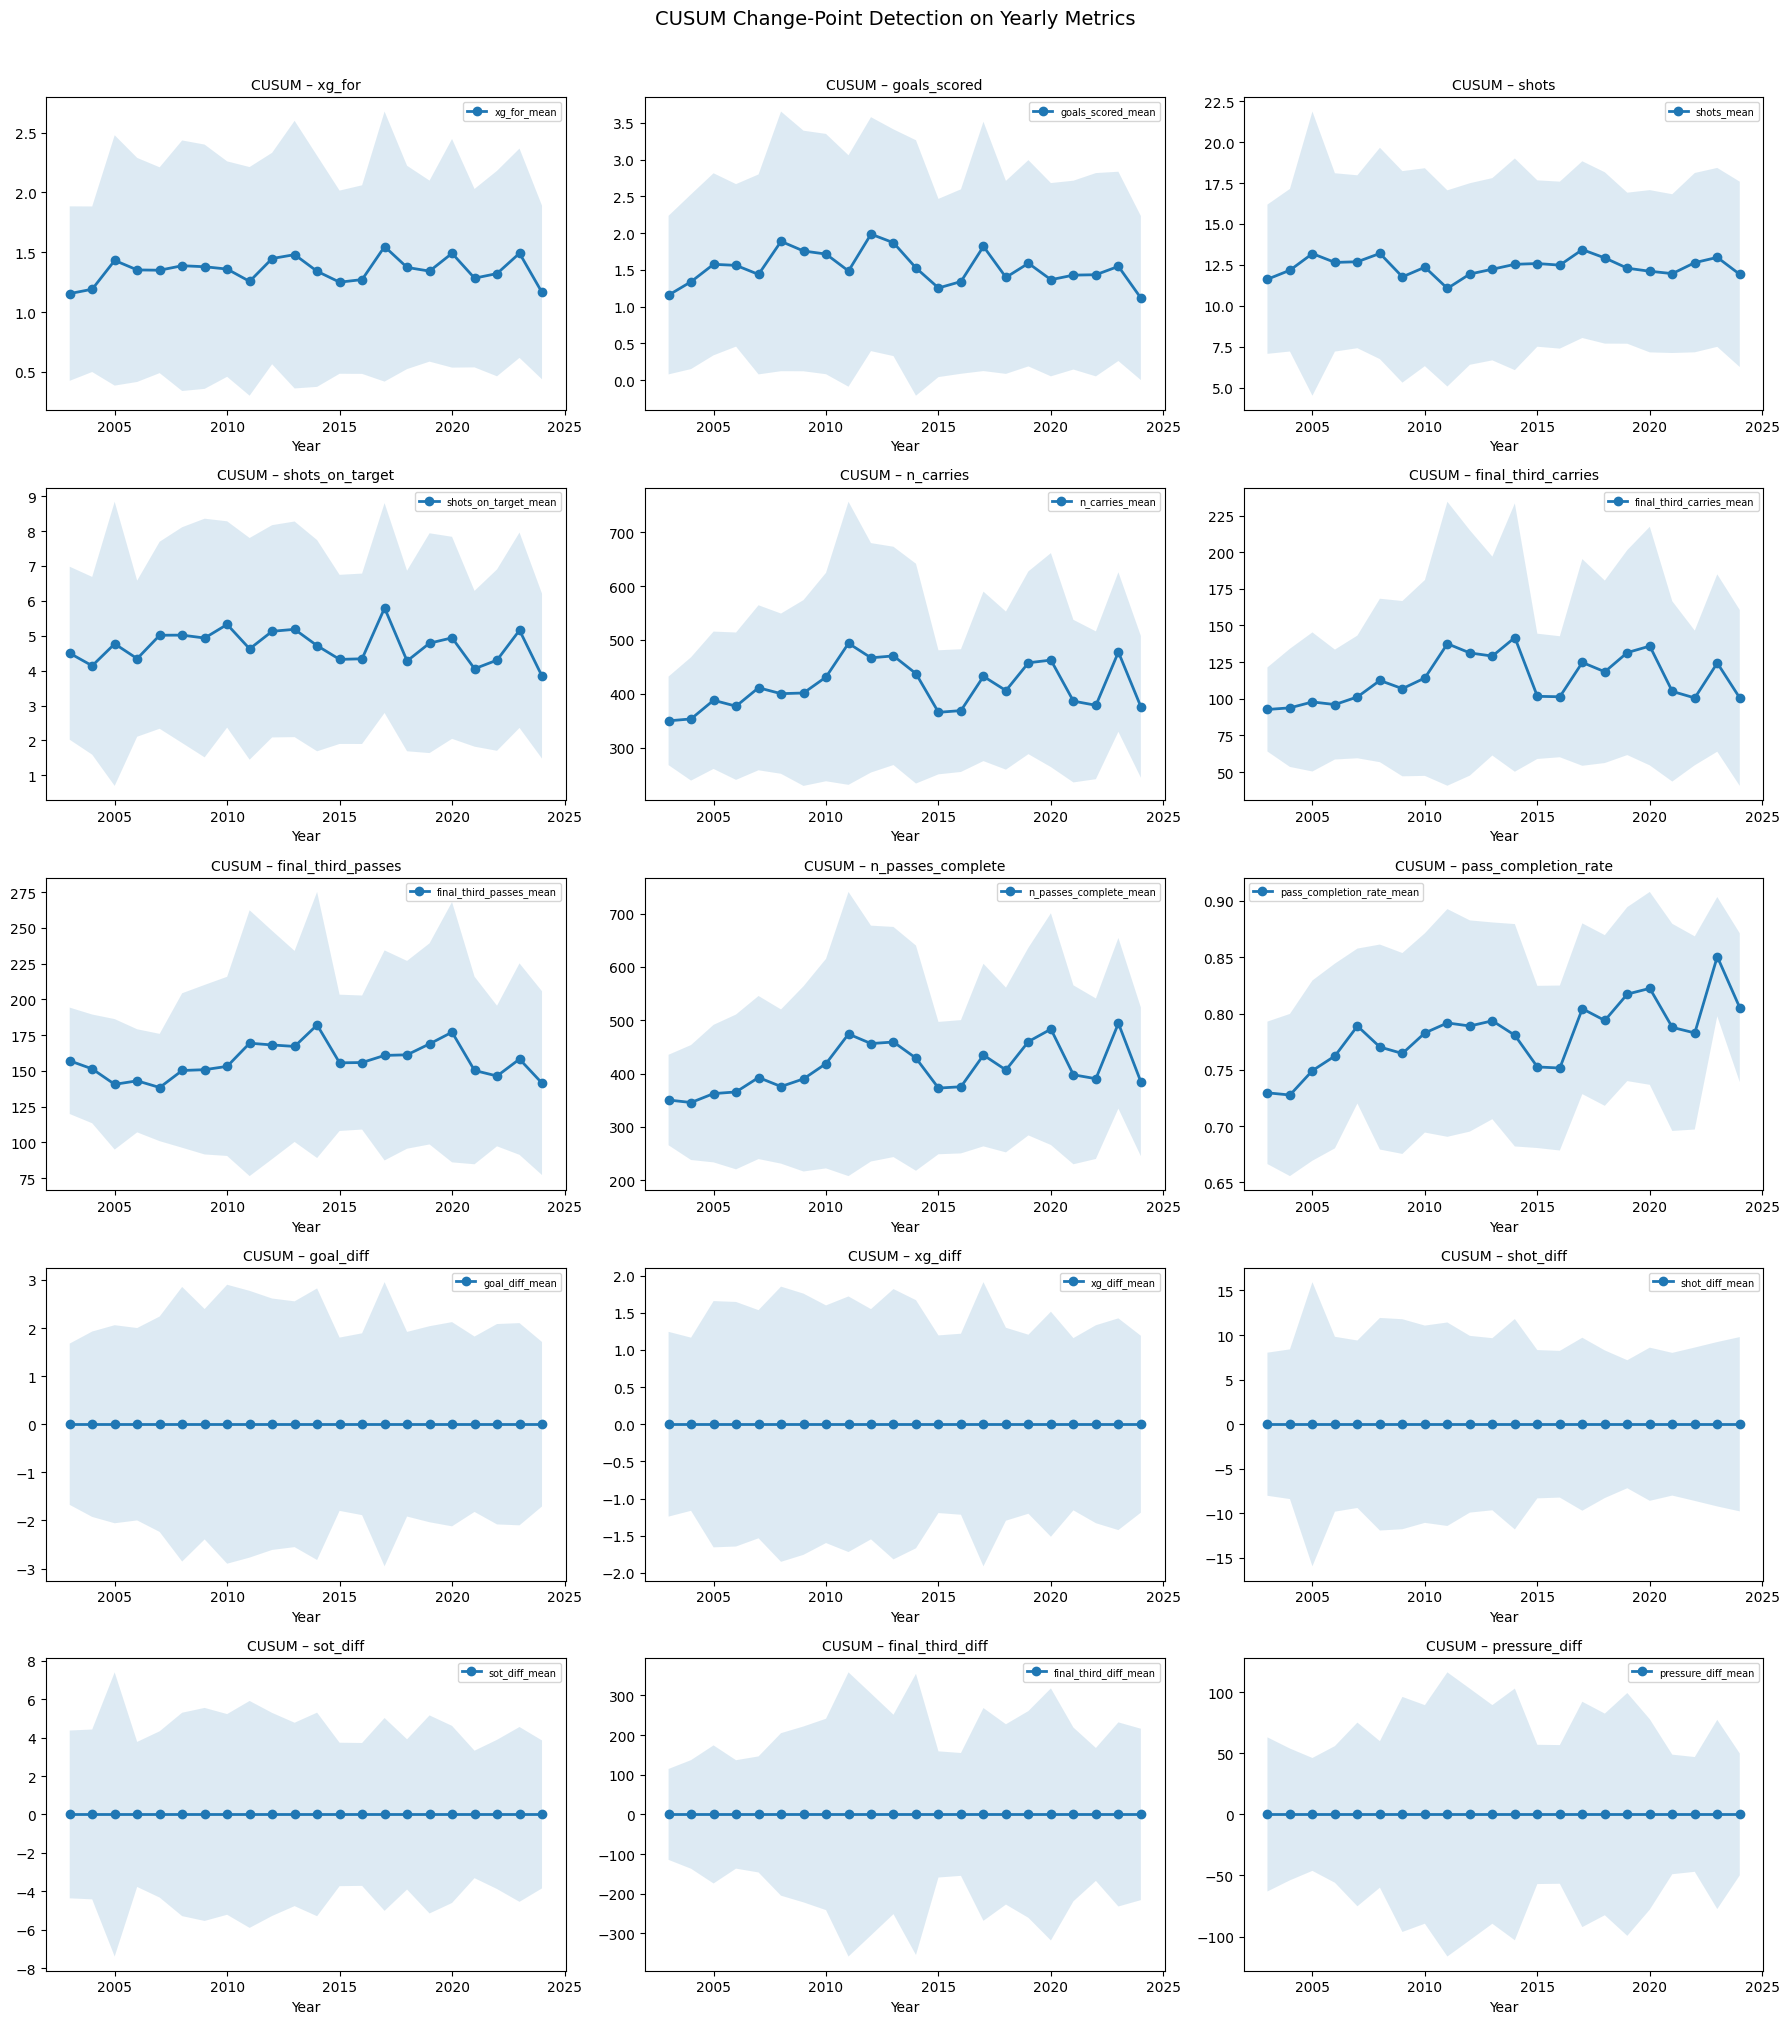

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

all_change_points = []   # collect for summary table

for i, f in enumerate(features):
    mean_col = f"{f}_mean"
    years = ts_pd["year"].values
    vals  = ts_pd[mean_col].values

    s_pos, s_neg, cp_up, cp_dn = cusum_detect(vals)

    # --- plot the metric ---
    axes[i].plot(years, vals, marker='o', linewidth=2, label=mean_col)

    # shade ±1 σ if available
    std_col = f"{f}_std"
    if std_col in ts_pd.columns:
        axes[i].fill_between(
            years,
            vals - ts_pd[std_col].values,
            vals + ts_pd[std_col].values,
            alpha=0.15
        )

    # --- mark change points ---
    for idx in cp_up:
        axes[i].axvline(years[idx], color='red', linestyle='--', linewidth=1.5,
                        label='Upward shift' if idx == cp_up[0] else '')
        all_change_points.append((years[idx], f, 'up'))
    for idx in cp_dn:
        axes[i].axvline(years[idx], color='blue', linestyle='--', linewidth=1.5,
                        label='Downward shift' if idx == cp_dn[0] else '')
        all_change_points.append((years[idx], f, 'down'))

    axes[i].set_title(f"CUSUM – {f}", fontsize=10)
    axes[i].set_xlabel("Year")
    axes[i].legend(fontsize=7, loc='best')

fig.suptitle("CUSUM Change-Point Detection on Yearly Metrics",
             fontsize=14, y=1.01)
fig.tight_layout()
plt.show()

In [24]:
import pandas as pd

cp_df = pd.DataFrame(all_change_points,
                      columns=["Year", "Feature", "Direction"])
cp_df = cp_df.sort_values(["Year", "Feature"]).reset_index(drop=True)
print(f"Total structural shifts detected: {len(cp_df)}")
cp_df

Total structural shifts detected: 0


,Year,Feature,Direction


# Modeling

In [25]:
best_features = ["sot_diff", "xg_diff", "shot_diff"]
best_features_no_xG = ['sot_diff', 'shot_diff', 'carry_diff', 'pass_diff', 'pass_complete_diff']
year_best_features = ["year", "sot_diff", "xg_diff", "shot_diff"]
year_best_features_no_xG = ['year', 'sot_diff', 'shot_diff', 'carry_diff', 'pass_diff', 'pass_complete_diff']

In [26]:
# === prepare_model_data(df, feature_cols) ===
def prepare_model_data(df, feature_cols):
    model_df = df.filter(pl.col("win").is_not_null())
    X = model_df.select(feature_cols).to_pandas()
    y = model_df.select("win").to_numpy().ravel()
    return X, y

In [27]:
# === MODEL 2 FORWARD SEARCH LR MODEL ===
# -------------------------------------------------------------------
# Model 2 Forward Selection Diff Vars only
# -------------------------------------------------------------------
candidates = ['xg_diff', 'shot_diff', 'sot_diff', 'final_third_diff', 'pressure_diff', 'pass_completion_rate', 'carry_diff', 'dribble_diff', 'pass_diff', 'pass_complete_diff', 'year']
X, y = prepare_model_data(df, feature_cols=candidates)

forced = ["year"]   # can be one or many required features

selected = forced.copy()
remaining = [c for c in candidates if c not in forced]

# baseline BIC for forced model
current_bic, _ = compute_bic(X[selected], y)

print(f"Forced in: {selected} | Starting BIC: {round(current_bic, 2)}")

while len(remaining) > 0:
    bic_with_candidates = []

    for candidate in remaining:
        X_candidate = X[selected + [candidate]]
        bic, _ = compute_bic(X_candidate, y)
        bic_with_candidates.append((bic, candidate))

    bic_with_candidates.sort()
    best_bic, best_candidate = bic_with_candidates[0]

    if best_bic < current_bic:
        selected.append(best_candidate)
        remaining.remove(best_candidate)
        current_bic = best_bic
        print(f"Added: {best_candidate} | BIC: {round(best_bic, 2)}")
    else:
        break

print("\nFinal selected variables:", selected)

Forced in: ['year'] | Starting BIC: 5997.21
Added: sot_diff | BIC: 3913.86
Added: xg_diff | BIC: 3583.31
Added: shot_diff | BIC: 3052.78

Final selected variables: ['year', 'sot_diff', 'xg_diff', 'shot_diff']


In [28]:
# === LR MODEL PERFORMANCE | FORWARD SEARCH PREDICTORS | FORCED YEAR FEATURE ===
features_selected = ['year', 'sot_diff', 'xg_diff', 'shot_diff']
X_sel, y = prepare_model_data(df, feature_cols=features_selected)
model2 = LogisticRegression()
acc_scores2 = cross_val_score(model2, X_sel, y, cv=5, scoring="accuracy")
auc_scores2 = cross_val_score(model2, X_sel, y, cv=5, scoring="roc_auc")
logreg_cv_results = cv_metrics(acc_scores2, auc_scores2, "Forward Search (no xG)")

display(logreg_cv_results)

,Model,Accuracy Mean,Accuracy StD,AUC Mean,AUC StD
0,Forward Search (no xG),0.849,0.027,0.922,0.022


In [29]:
# === LR MODEL PERFORMANCE | FORWARD SEARCH PREDICTORS | FORCED YEAR FEATURE ===
features_selected = ['year', 'sot_diff', 'shot_diff', 'carry_diff', 'pass_diff', 'pass_complete_diff']
X_sel, y = prepare_model_data(df, feature_cols=features_selected)
model2 = LogisticRegression()
acc_scores2 = cross_val_score(model2, X_sel, y, cv=5, scoring="accuracy")
auc_scores2 = cross_val_score(model2, X_sel, y, cv=5, scoring="roc_auc")
logreg_cv_results = pd.concat([
    logreg_cv_results,
    cv_metrics(acc_scores2, auc_scores2, "Forward Search (no xG)")
], ignore_index=True).drop_duplicates()

display(logreg_cv_results)

,Model,Accuracy Mean,Accuracy StD,AUC Mean,AUC StD
0,Forward Search (no xG),0.849,0.027,0.922,0.022
1,Forward Search (no xG),0.804,0.032,0.892,0.026


# AUC vs. Match Minute — In-Match Signal Accumulation

**Research question:** *How early in a match can we reliably predict the final result?*

We compute cumulative in-match features (xG diff, shots on target diff, shot diff,
pressure diff, carry diff, etc.) at progressive minute cutoffs and fit a logistic
regression at each cutoff to predict the final match outcome (Win/Loss).

The resulting **AUC-vs-Minute curve** starts at the ELO pre-match baseline (minute 0)
and shows how predictive accuracy improves as more match information is observed.
The gap between 0.778 (pre-match) and the curve quantifies the marginal value of
in-match signals at each phase of the game.

In [30]:
# === AUC vs. Match Minute Curve ===
# Compute cumulative features at each minute cutoff, then evaluate
# logistic regression AUC for predicting the final match result.

from sklearn.model_selection import StratifiedKFold

MINUTE_CUTOFFS = [5, 10, 15, 30, 45, 60, 75, 90]
FEATURE_COLS = ['xg_diff', 'sot_diff', 'shot_diff', 'pressure_diff',
                'carry_diff', 'pass_diff', 'final_third_diff']

auc_results = []

for cutoff in MINUTE_CUTOFFS:
    print(f"Processing minute cutoff: {cutoff}...")
    
    # Filter events to only those occurring at or before the cutoff minute
    events_window = events_df.filter(pl.col('minute') <= cutoff)
    
    # Build feature matrix using existing function
    # Use ot=True because some teams may have zero events in early windows
    window_matrix = create_match_results_matrix(events_window, match_results, ot=True)
    
    # Join with matches for year (needed for filtering) and add win column
    window_df = window_matrix.join(
        matches.select(['match_id', 'match_date', 'year']),
        on='match_id', how='inner'
    )
    
    # Prepare modeling data — filter out draws
    model_df = window_df.filter(pl.col('win').is_not_null())
    
    # Check available features (some may be all-zero in early windows)
    available_feats = [f for f in FEATURE_COLS if f in model_df.columns]
    
    X = model_df.select(available_feats).to_pandas().fillna(0)
    y = model_df.select('win').to_numpy().ravel()
    
    # Stratified 5-fold CV
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_aucs = []
    fold_accs = []
    for train_idx, test_idx in skf.split(X, y):
        lr = LogisticRegression(max_iter=1000)
        lr.fit(X.iloc[train_idx], y[train_idx])
        proba = lr.predict_proba(X.iloc[test_idx])[:, 1]
        fold_aucs.append(roc_auc_score(y[test_idx], proba))
        fold_accs.append(accuracy_score(y[test_idx], lr.predict(X.iloc[test_idx])))
    
    auc_results.append({
        'minute': cutoff,
        'auc_mean': np.mean(fold_aucs),
        'auc_std': np.std(fold_aucs),
        'acc_mean': np.mean(fold_accs),
        'acc_std': np.std(fold_accs),
        'n_samples': len(y)
    })

auc_curve_df = pd.DataFrame(auc_results)
print('\n=== AUC vs. Minute Results ===')
display(auc_curve_df.round(3))

Processing minute cutoff: 5...
Processing minute cutoff: 10...
Processing minute cutoff: 15...
Processing minute cutoff: 30...
Processing minute cutoff: 45...
Processing minute cutoff: 60...
Processing minute cutoff: 75...
Processing minute cutoff: 90...

=== AUC vs. Minute Results ===


,minute,auc_mean,auc_std,acc_mean,acc_std,n_samples
0,5,0.733,0.017,0.677,0.014,4314
1,10,0.766,0.019,0.697,0.023,4314
2,15,0.779,0.026,0.702,0.019,4314
3,30,0.815,0.012,0.734,0.011,4314
4,45,0.848,0.008,0.762,0.015,4314
5,60,0.874,0.011,0.787,0.014,4314
6,75,0.893,0.012,0.806,0.013,4314
7,90,0.918,0.004,0.831,0.003,4314


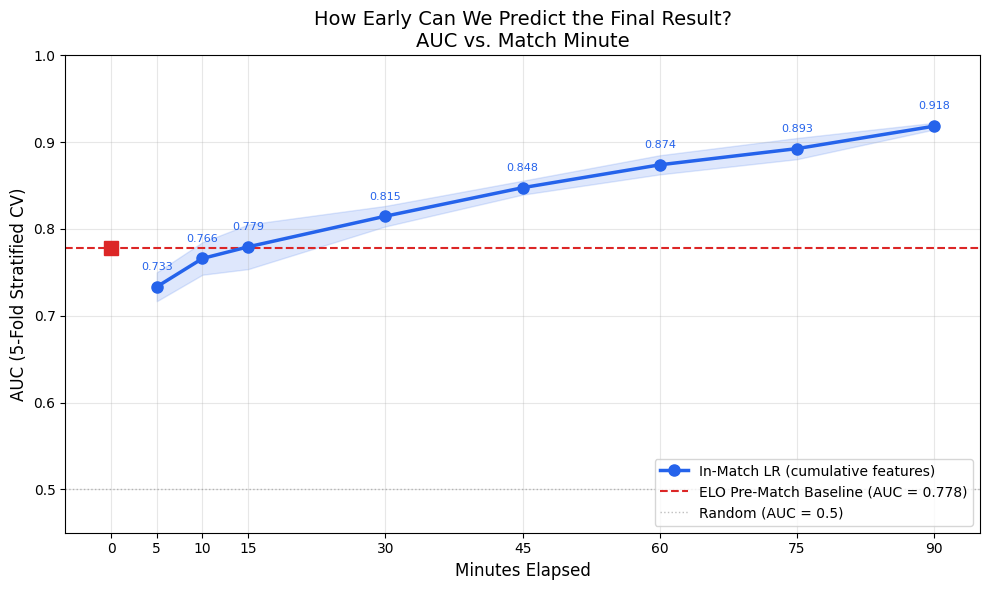

In [31]:
# === PLOT: AUC vs. Match Minute ===
ELO_BASELINE_AUC = 0.778   # from PreMatch_Baseline_Models.ipynb

fig, ax = plt.subplots(figsize=(10, 6))

# Plot the in-match AUC curve with error bands
ax.plot(auc_curve_df['minute'], auc_curve_df['auc_mean'],
        'o-', color='#2563eb', linewidth=2.5, markersize=8, label='In-Match LR (cumulative features)', zorder=3)
ax.fill_between(auc_curve_df['minute'],
                auc_curve_df['auc_mean'] - auc_curve_df['auc_std'],
                auc_curve_df['auc_mean'] + auc_curve_df['auc_std'],
                alpha=0.15, color='#2563eb')

# ELO baseline at minute 0
ax.axhline(y=ELO_BASELINE_AUC, color='#dc2626', linestyle='--', linewidth=1.5,
           label=f'ELO Pre-Match Baseline (AUC = {ELO_BASELINE_AUC})')
ax.plot(0, ELO_BASELINE_AUC, 's', color='#dc2626', markersize=10, zorder=3)

# Random baseline
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5, label='Random (AUC = 0.5)')

# Annotate each point
for _, row in auc_curve_df.iterrows():
    ax.annotate(f"{row['auc_mean']:.3f}",
                (row['minute'], row['auc_mean']),
                textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=8, color='#2563eb')

ax.set_xlabel('Minutes Elapsed', fontsize=12)
ax.set_ylabel('AUC (5-Fold Stratified CV)', fontsize=12)
ax.set_title('How Early Can We Predict the Final Result?\nAUC vs. Match Minute', fontsize=14)
ax.set_xlim(-5, 95)
ax.set_ylim(0.45, 1.0)
ax.set_xticks([0] + MINUTE_CUTOFFS)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [32]:
# === Marginal Information Gain Table ===
# How much AUC does each phase of the match add over pre-match?

marginal_df = auc_curve_df.copy()
marginal_df['auc_over_baseline'] = marginal_df['auc_mean'] - ELO_BASELINE_AUC
marginal_df['auc_over_baseline_pct'] = (marginal_df['auc_over_baseline'] / (1.0 - ELO_BASELINE_AUC) * 100)
marginal_df['marginal_gain'] = marginal_df['auc_mean'].diff().fillna(
    marginal_df['auc_mean'].iloc[0] - ELO_BASELINE_AUC
)

print('=== Marginal Information Gain Over Pre-Match Baseline ===')
print(f'ELO Pre-Match Baseline AUC: {ELO_BASELINE_AUC}')
print(f'Theoretical ceiling (perfect): 1.000')
print(f'Gap to close: {1.0 - ELO_BASELINE_AUC:.3f}\n')

display(marginal_df[['minute', 'auc_mean', 'auc_over_baseline',
                      'auc_over_baseline_pct', 'marginal_gain']].round(3))

=== Marginal Information Gain Over Pre-Match Baseline ===
ELO Pre-Match Baseline AUC: 0.778
Theoretical ceiling (perfect): 1.000
Gap to close: 0.222



,minute,auc_mean,auc_over_baseline,auc_over_baseline_pct,marginal_gain
0,5,0.733,-0.045,-20.126,-0.045
1,10,0.766,-0.012,-5.413,0.033
2,15,0.779,0.001,0.631,0.013
3,30,0.815,0.037,16.530,0.035
4,45,0.848,0.070,31.310,0.033
5,60,0.874,0.096,43.186,0.026
6,75,0.893,0.115,51.596,0.019
7,90,0.918,0.140,63.247,0.026


# In-Match CUSUM — When Does Dominance Become Decisive?

The season-level CUSUM above showed that soccer's statistical patterns are **stable across 20 years**.
Now we apply the same CUSUM framework **within individual matches**, tracking the cumulative
xG difference minute-by-minute.

**Key question:** *At what minute does cumulative on-pitch dominance reliably signal the final result?*

For each match we build a minute-by-minute cumulative xG difference time series (home − away).
We then run two-sided CUSUM on each match's series. A CUSUM signal means the cumulative
dominance has exceeded the detection threshold — the match has tilted decisively.

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Drift *k* | 0.5 σ | Same as season-level CUSUM |
| Threshold *h* | 4 σ | Consistent framework across both analyses |

In [33]:
# === In-Match CUSUM: Minute-by-Minute Cumulative xG Difference ===

# Step 1: Get home/away team labels from matches
home_away = matches.select(['match_id', 'home_team', 'away_team'])

# Step 2: Build minute-by-minute xG for each team in each match
shot_events = events_df.filter(pl.col('type') == 'Shot').select(
    ['match_id', 'team', 'minute', 'shot_statsbomb_xg']
).with_columns(pl.col('shot_statsbomb_xg').fill_null(0.0))

# Aggregate xG per match-team-minute
xg_per_minute = (
    shot_events
    .group_by(['match_id', 'team', 'minute'])
    .agg(pl.col('shot_statsbomb_xg').sum().alias('xg'))
)

# Step 3: For each match, build cumulative xG diff (home - away) at each minute
match_ids = home_away.select('match_id').to_series().to_list()
ha_pd = home_away.to_pandas()
xg_pd = xg_per_minute.to_pandas()

cusum_results = []  # per-match CUSUM summary
sample_matches = []  # store a few for plotting

for _, mrow in ha_pd.iterrows():
    mid = mrow['match_id']
    ht, at = mrow['home_team'], mrow['away_team']
    
    # Get xG events for this match
    match_xg = xg_pd[xg_pd['match_id'] == mid]
    home_xg = match_xg[match_xg['team'] == ht].set_index('minute')['xg']
    away_xg = match_xg[match_xg['team'] == at].set_index('minute')['xg']
    
    # Build minute-by-minute cumulative xG diff from minute 1 to 90
    minutes = range(1, 91)
    cum_xg_diff = []
    running_diff = 0.0
    for m in minutes:
        running_diff += home_xg.get(m, 0.0) - away_xg.get(m, 0.0)
        cum_xg_diff.append(running_diff)
    
    cum_xg_diff = np.array(cum_xg_diff)
    
    # Skip matches with no shots (flat zero series)
    if np.std(cum_xg_diff) == 0:
        continue
    
    # Apply CUSUM (reuse existing function)
    s_pos, s_neg, cp_up, cp_dn = cusum_detect(cum_xg_diff)
    
    # Find earliest change point (either direction)
    all_cps = sorted(cp_up + cp_dn)
    first_cp_minute = (all_cps[0] + 1) if len(all_cps) > 0 else None  # +1 for 1-based
    
    cusum_results.append({
        'match_id': mid,
        'n_signals': len(all_cps),
        'first_signal_minute': first_cp_minute,
        'has_signal': len(all_cps) > 0,
        'final_xg_diff': cum_xg_diff[-1]
    })
    
    # Store a few sample matches for plotting
    if len(sample_matches) < 6 and len(all_cps) > 0:
        sample_matches.append({
            'match_id': mid, 'home': ht, 'away': at,
            'cum_xg_diff': cum_xg_diff, 's_pos': s_pos, 's_neg': s_neg,
            'cp_up': cp_up, 'cp_dn': cp_dn
        })

cusum_df = pd.DataFrame(cusum_results)
print(f'Matches analyzed: {len(cusum_df)}')
print(f'Matches with CUSUM signal: {cusum_df["has_signal"].sum()} ({cusum_df["has_signal"].mean()*100:.1f}%)')
print(f'Matches without signal: {(~cusum_df["has_signal"]).sum()} ({(~cusum_df["has_signal"]).mean()*100:.1f}%)')

Matches analyzed: 2889
Matches with CUSUM signal: 2889 (100.0%)
Matches without signal: 0 (0.0%)


=== Cumulative % of Matches with CUSUM Signal by Minute ===


,by_minute,n_signaled,pct_of_all,pct_of_signaled
0,5,744,25.8,25.8
1,10,1728,59.8,59.8
2,15,2046,70.8,70.8
3,30,2499,86.5,86.5
4,45,2702,93.5,93.5
5,60,2815,97.4,97.4
6,75,2851,98.7,98.7
7,90,2889,100.0,100.0


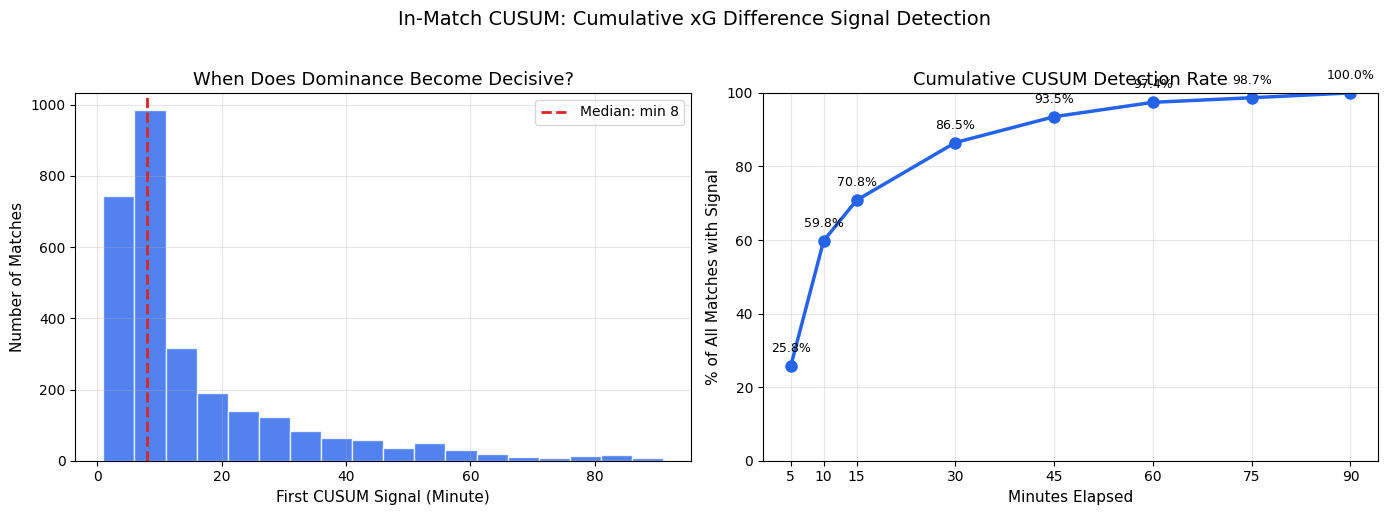

In [34]:
# === CUSUM Signal Timing: When does dominance become decisive? ===

signaled = cusum_df[cusum_df['has_signal']].copy()

# Cumulative % of matches that have received a signal by each minute
minute_bins = [5, 10, 15, 30, 45, 60, 75, 90]
pct_signaled = []
for m in minute_bins:
    n_by_m = (signaled['first_signal_minute'] <= m).sum()
    pct_signaled.append({
        'by_minute': m,
        'n_signaled': n_by_m,
        'pct_of_all': n_by_m / len(cusum_df) * 100,
        'pct_of_signaled': n_by_m / len(signaled) * 100 if len(signaled) > 0 else 0
    })

signal_timing_df = pd.DataFrame(pct_signaled)
print('=== Cumulative % of Matches with CUSUM Signal by Minute ===')
display(signal_timing_df.round(1))

# Distribution of first signal minute
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of first signal minute
axes[0].hist(signaled['first_signal_minute'], bins=range(1, 92, 5),
             color='#2563eb', edgecolor='white', alpha=0.8)
axes[0].set_xlabel('First CUSUM Signal (Minute)', fontsize=11)
axes[0].set_ylabel('Number of Matches', fontsize=11)
axes[0].set_title('When Does Dominance Become Decisive?', fontsize=13)
axes[0].axvline(signaled['first_signal_minute'].median(), color='#dc2626',
                linestyle='--', linewidth=2,
                label=f"Median: min {signaled['first_signal_minute'].median():.0f}")
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Right: cumulative % signaled curve
axes[1].plot(signal_timing_df['by_minute'], signal_timing_df['pct_of_all'],
             'o-', color='#2563eb', linewidth=2.5, markersize=8)
axes[1].set_xlabel('Minutes Elapsed', fontsize=11)
axes[1].set_ylabel('% of All Matches with Signal', fontsize=11)
axes[1].set_title('Cumulative CUSUM Detection Rate', fontsize=13)
axes[1].set_ylim(0, 100)
axes[1].set_xticks(minute_bins)
for _, row in signal_timing_df.iterrows():
    axes[1].annotate(f"{row['pct_of_all']:.1f}%",
                     (row['by_minute'], row['pct_of_all']),
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', fontsize=9)
axes[1].grid(True, alpha=0.3)

fig.suptitle('In-Match CUSUM: Cumulative xG Difference Signal Detection',
             fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

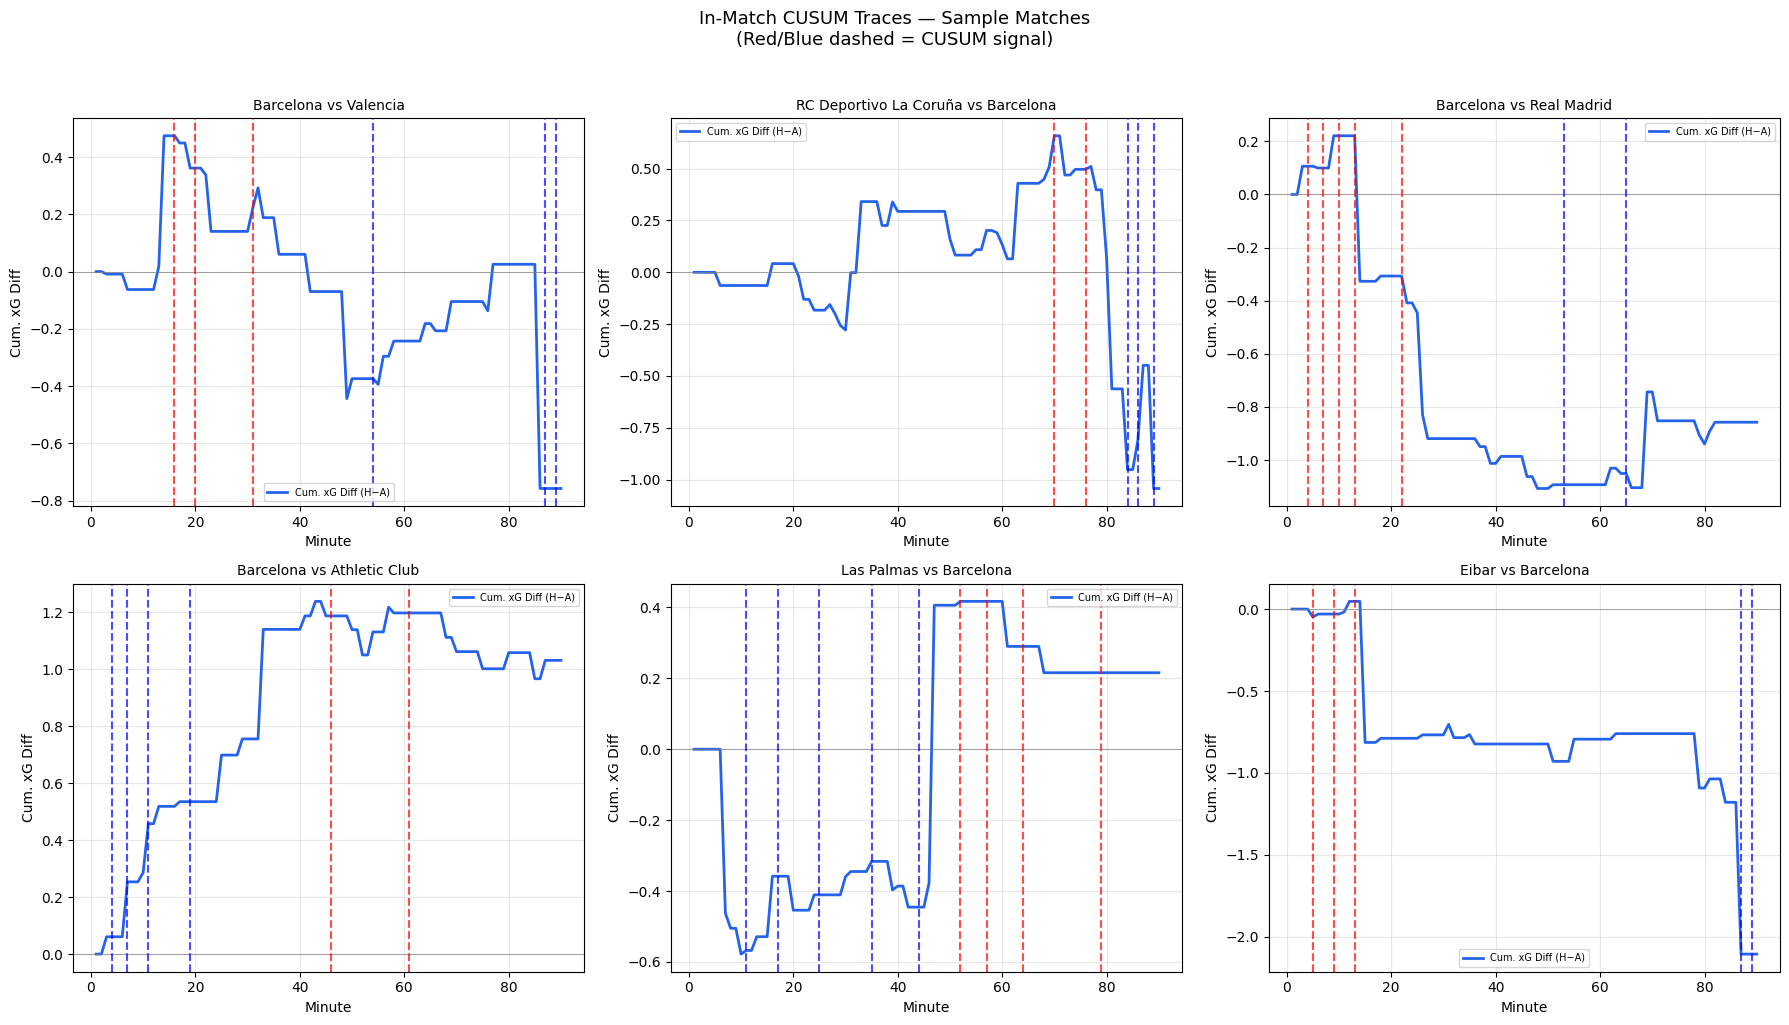

In [35]:
# === Sample Match CUSUM Traces ===
# Visualize cumulative xG diff and CUSUM statistics for individual matches

n_samples = min(6, len(sample_matches))
if n_samples > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    for i, sm in enumerate(sample_matches[:n_samples]):
        mins = range(1, 91)
        ax = axes[i]
        
        # Plot cumulative xG diff
        ax.plot(mins, sm['cum_xg_diff'], color='#2563eb', linewidth=2,
                label='Cum. xG Diff (H−A)')
        ax.axhline(0, color='gray', linestyle='-', linewidth=0.5)
        
        # Mark CUSUM change points
        for cp in sm['cp_up']:
            ax.axvline(cp + 1, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        for cp in sm['cp_dn']:
            ax.axvline(cp + 1, color='blue', linestyle='--', linewidth=1.5, alpha=0.7)
        
        ax.set_title(f"{sm['home']} vs {sm['away']}", fontsize=10)
        ax.set_xlabel('Minute')
        ax.set_ylabel('Cum. xG Diff')
        ax.legend(fontsize=7, loc='best')
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for j in range(n_samples, 6):
        axes[j].set_visible(False)
    
    fig.suptitle('In-Match CUSUM Traces — Sample Matches\n(Red/Blue dashed = CUSUM signal)',
                 fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()
else:
    print('No matches with CUSUM signals to plot.')

In [36]:
# === CUSUM Signal vs. Actual Outcome ===
# Does the direction of the first CUSUM signal predict who wins?

# Join CUSUM results with actual match outcomes
outcomes = match_results.to_pandas()
outcomes_home = outcomes.merge(
    ha_pd, on='match_id'
).query('team == home_team')[['match_id', 'result']].rename(columns={'result': 'home_result'})

cusum_with_result = cusum_df.merge(outcomes_home, on='match_id', how='inner')
cusum_signaled = cusum_with_result[cusum_with_result['has_signal']].copy()

# Classify: positive final xG diff = home dominated, negative = away dominated
cusum_signaled['predicted_winner'] = cusum_signaled['final_xg_diff'].apply(
    lambda x: 'Win' if x > 0 else 'Loss'
)
cusum_signaled['correct'] = cusum_signaled['predicted_winner'] == cusum_signaled['home_result']

# Filter out draws for fair comparison
cusum_no_draw = cusum_signaled[cusum_signaled['home_result'] != 'Draw']

print('=== CUSUM Signal Direction vs. Actual Outcome ===')
print(f'Matches with signal (excl. draws): {len(cusum_no_draw)}')
print(f'Signal matches actual winner: {cusum_no_draw["correct"].sum()} ({cusum_no_draw["correct"].mean()*100:.1f}%)')
print(f'\nFor reference:')
print(f'  ELO pre-match accuracy: 69.0%')
print(f'  Always pick home: ~58.7%')

=== CUSUM Signal Direction vs. Actual Outcome ===
Matches with signal (excl. draws): 2157
Signal matches actual winner: 1683 (78.0%)

For reference:
  ELO pre-match accuracy: 69.0%
  Always pick home: ~58.7%
